In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from statsmodels.stats.contingency_tables import mcnemar

In [10]:
sns.set_theme(style="darkgrid")

In [11]:
data_path = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\data'
df = pd.read_csv(os.path.join(data_path, 'kepler_clean.csv'))

TARGET = 'koi_disposition'
df_model = df[df[TARGET].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_score', 'koi_depth',
    'koi_duration', 'koi_impact',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]

X = df_model[KEY_FEATURES]
y_raw = df_model[TARGET]

le = LabelEncoder()
y = le.fit_transform(y_raw)

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

#Group-aware aplit by host star (ra/dec proxy)
df_model['star_id'] = df_model['ra'].round(5).astype(str) + '-' + df_model['dec'].round(5).astype(str)
groups = df_model['star_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Star overlap: {len(set(df_model.iloc[train_idx]['star_id']) & set(df_model.iloc[test_idx]['star_id']))}")

Train size: 4,945 | Test size: 1,258
Star overlap: 0


In [12]:
FEATURE_TIERS = {
    'Full': KEY_FEATURES,
    'No koi_score': [f for f in KEY_FEATURES if f != 'koi_score'],
    'Raw physical': [f for f in KEY_FEATURES if f not in [
        'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
    ]]
}

models_template = {
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                     subsample=0.8, colsample_bytree=0.8,
                                     use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Gradient Boosting': lambda: GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42),
    'SVM': lambda: SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

tier_results = {}

for tier_name, features in FEATURE_TIERS.items():
    print(f"\n{'='*70}\nTIER: {tier_name} ({len(features)} features)\n{'='*70}")

    X_train_tier = pd.DataFrame(X_train_bal, columns=KEY_FEATURES)[features]
    X_test_tier = pd.DataFrame(X_test_imp, columns=KEY_FEATURES)[features]

    scaler_tier = StandardScaler()
    X_train_tier_scaled = scaler_tier.fit_transform(X_train_tier)
    X_test_tier_scaled = scaler_tier.transform(X_test_tier)

    tier_results[tier_name] = {}
    for name, make_model in models_template.items():
        model = make_model()
        if name == 'SVM':
            model.fit(X_train_tier_scaled, y_train_bal)
            y_pred = model.predict(X_test_tier_scaled)
            y_prob = model.predict_proba(X_test_tier_scaled)[:, 1]
        else:
            model.fit(X_train_tier, y_train_bal)
            y_pred = model.predict(X_test_tier_scaled)
            y_prob = model.predict_proba(X_test_tier)[:, 1]

        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        tier_results[tier_name][name] = {
            'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'f1': f1, 'auc': auc,
            'X_test': X_test_tier if name != 'SVM' else X_test_tier_scaled
        }
        print(f" {name:<20} F1={f1:.4f} | AUC={auc:.4f}")


TIER: Full (16 features)
 Random Forest        F1=0.9935 | AUC=0.9990
 XGBoost              F1=0.9935 | AUC=0.9995
 Gradient Boosting    F1=0.9935 | AUC=0.9996
 SVM                  F1=0.9961 | AUC=0.9981

TIER: No koi_score (15 features)
 Random Forest        F1=0.9941 | AUC=0.9986
 XGBoost              F1=0.9948 | AUC=0.9992
 Gradient Boosting    F1=0.9948 | AUC=0.9989
 SVM                  F1=0.9941 | AUC=0.9985

TIER: Raw physical (11 features)
 Random Forest        F1=0.7557 | AUC=0.9741
 XGBoost              F1=0.7557 | AUC=0.9788
 Gradient Boosting    F1=0.7557 | AUC=0.9767
 SVM                  F1=0.8852 | AUC=0.9518


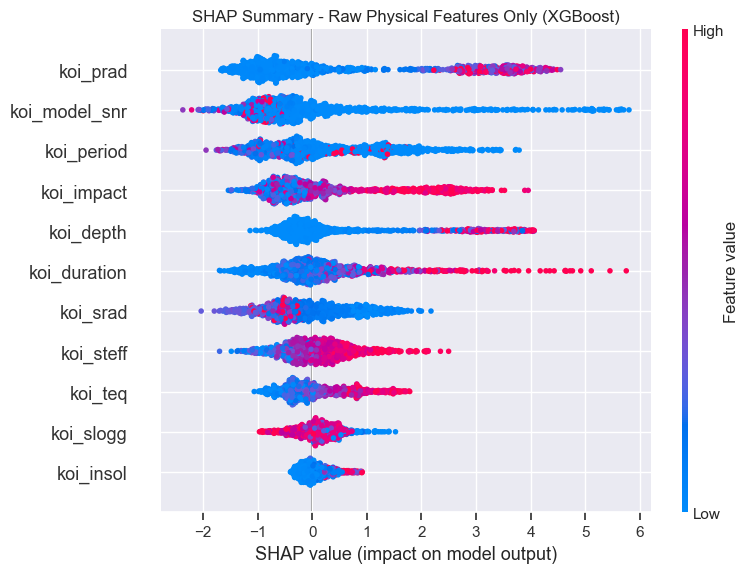

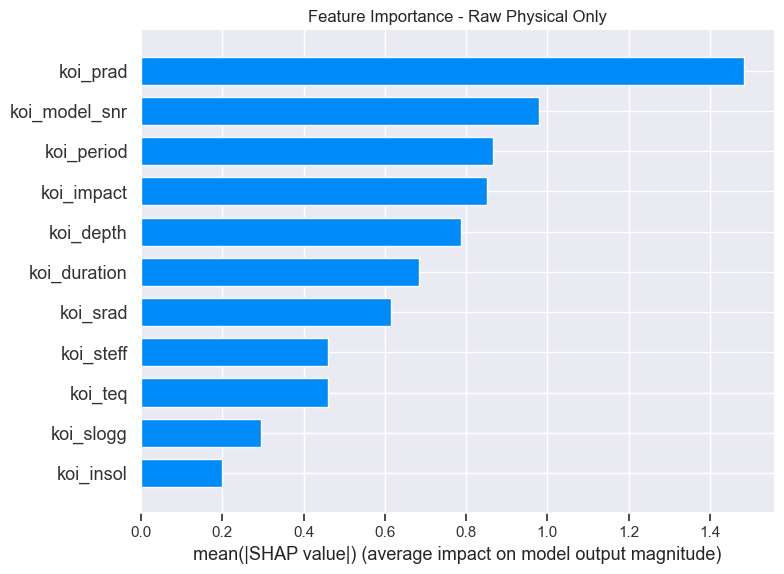

In [13]:
BASE = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project'
raw_features = FEATURE_TIERS['Raw physical']
raw_xgb_model = tier_results['Raw physical']['XGBoost']['model']
X_test_raw_for_shap = tier_results['Raw physical']['XGBoost']['X_test']

explainer_raw = shap.TreeExplainer(raw_xgb_model)
shap_values_raw = explainer_raw.shap_values(X_test_raw_for_shap)

plt.figure()
shap.summary_plot(shap_values_raw, X_test_raw_for_shap, feature_names=raw_features, show=False)
plt.title("SHAP Summary - Raw Physical Features Only (XGBoost)")
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p8_shap_raw_physical.png'), dpi=150, bbox_inches = 'tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values_raw, X_test_raw_for_shap, feature_names=raw_features,
                  plot_type='bar', show=False)
plt.title("Feature Importance - Raw Physical Only")
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p8_shap_raw_physical_bar.png'), dpi=150, bbox_inches = 'tight')
plt.show()

In [14]:
def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    both_correct = np.sum(correct_a & correct_b)
    a_only = np.sum(correct_a & ~correct_b)
    b_only = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)

    print(f"{name_a} vs {name_b}")
    print(f" Both correct: {both_correct} | {name_a} only: {a_only} | {name_b} only: {b_only} | Both wrong: {both_wrong}")

    if a_only == 0 and b_only == 0:
        print(" No discordant pairs - identical predictions. Treated as not significant.\n")
        return 1.0

    table = [[both_correct, a_only], [b_only, both_wrong]]
    use_exact = (a_only + b_only) < 25
    result = mcnemar(table, exact=use_exact, correction=not use_exact)
    sig = "Significant" if result.pvalue < 0.05 else "Not significant"
    print(f" Statistic: {result.statistic:.4f} | p-value: {result.pvalue:.4f} -> {sig}\n")
    return result.pvalue

print("MCNEMAR'S TEST - Across Feature Tiers (XGBoost)")
print("=" * 70)

xgb_full_pred = tier_results['Full']['XGBoost']['y_pred']
xgb_noscore_pred = tier_results['No koi_score']['XGBoost']['y_pred']
xgb_raw_pred = tier_results['Raw physical']['XGBoost']['y_pred']

mcnemar_test(y_test, xgb_full_pred, xgb_noscore_pred, 'Full', 'No koi_score')
mcnemar_test(y_test, xgb_full_pred, xgb_raw_pred, 'Full', 'Raw Physical')
mcnemar_test(y_test, xgb_noscore_pred, xgb_raw_pred, 'Noi koi_score', 'Raw Physical')

MCNEMAR'S TEST - Across Feature Tiers (XGBoost)
Full vs No koi_score
 Both correct: 1246 | Full only: 2 | No koi_score only: 4 | Both wrong: 6
 Statistic: 2.0000 | p-value: 0.6875 -> Not significant

Full vs Raw Physical
 Both correct: 764 | Full only: 484 | Raw Physical only: 0 | Both wrong: 10
 Statistic: 482.0021 | p-value: 0.0000 -> Significant

Noi koi_score vs Raw Physical
 Both correct: 764 | Noi koi_score only: 486 | Raw Physical only: 0 | Both wrong: 8
 Statistic: 484.0021 | p-value: 0.0000 -> Significant



np.float64(2.876817562134096e-107)